# V3.3 — Blackbody emission, smoke & derived appearance  **TIER 3 / the fire's look**

**Claim (pre-registered).** The implementation appearance map (`nebula.geometry.appearance`) derives the fire's look from physics: flame/ember EMISSION is blackbody incandescence (Planckian-locus color + T^4 intensity), SMOKE opacity is Beer–Lambert in the soot column, and SURFACE reflectance is derived from state (char darkens toward soot-black & roughens; moisture darkens). It must match the independent blackbody oracle within LUT tolerance.

**Why load-bearing.** Blocker #2: Phase-0's flame was a constant emissive `[1.0,0.55,0.12]` + a linear `(T-650)/450` ramp — no Wien hue shift, no T^4, no smoke. Blocker #6: surface was flat vertex tints. Real fire color IS blackbody; getting it physical is what stops it reading as CG.

**Independent oracle.** `blackbody.py` — Planck's law, Wien displacement, Stefan–Boltzmann, the CIE Planckian-locus color (Wyman-2013 analytic CMFs), and Beer–Lambert. The implementation ports this into a fast LUT; this notebook checks PARITY (the parity-test discipline).

**Pre-registered pass criteria (frozen below measured margins):**

| # | Metric | Threshold |
|---|---|---|
| C1 | blackbody color parity: max \|appearance LUT − oracle sRGB\| over 700–3000 K | < 0.05 |
| C2 | Planckian locus: B/R chromaticity ratio monotone↑ in T; 900 K is red | monotone AND R>B at 900 K |
| C3 | emission ∝ T^4 (Stefan–Boltzmann), and cold wood (≤T_on) does not emit | ratio(1500/750)=16±1e-6 AND e(700)=0 |
| C4 | derived surface: char darkens & roughens, wet darkens, only hot char emits | all monotone AND char albedo ≈ soot ref |
| C5 | smoke opacity vs soot column matches Beer–Lambert oracle | max abs diff < 1e-9 |

In [1]:
import sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
ROOT = pathlib.Path.cwd().resolve()
while ROOT.name and not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src' / 'implementation'))
sys.path.insert(0, str(ROOT / 'src' / 'verification' / 'oracles'))
from nebula.geometry import appearance as ap
import blackbody as bb
np.seterr(all='ignore')
R = {}
print('appearance map + blackbody oracle loaded')

appearance map + blackbody oracle loaded


In [2]:
# C1 parity vs oracle across the flame range
Ts = np.linspace(700, 3000, 40)
lut = ap.blackbody_rgb(Ts)
orc = np.array([bb.blackbody_srgb(T) for T in Ts])
R['C1_parity'] = float(np.abs(lut - orc).max())
# C2 Planckian locus monotone
br = (lut[:, 2] + 1e-6) / (lut[:, 0] + 1e-6)
R['C2_mono'] = bool(np.all(np.diff(br) >= -1e-6)); R['C2_red900'] = bool(ap.blackbody_rgb(900)[0,0] > ap.blackbody_rgb(900)[0,2])
# C3 T^4 emission
R['C3_ratio'] = float(ap.emission_intensity(1500, T_on=0, T_full=3000) / ap.emission_intensity(750, T_on=0, T_full=3000))
R['C3_coldoff'] = float(ap.emission_intensity(700.0))
print(f"C1 parity max|Δ| {R['C1_parity']:.3f} (<0.05)")
print(f"C2 B/R monotone {R['C2_mono']}; 900K red {R['C2_red900']}")
print(f"C3 emission(1500)/(750) {R['C3_ratio']:.2f} (=16); emission(700K)={R['C3_coldoff']}")

C1 parity max|Δ| 0.007 (<0.05)
C2 B/R monotone True; 900K red True
C3 emission(1500)/(750) 16.00 (=16); emission(700K)=0.0


In [3]:
# C4 derived surface map
bark = np.array([0.40, 0.26, 0.13])
fresh = ap.surface_appearance(bark)
charred = ap.surface_appearance(bark, T=1400.0, chi=0.9)
wet = ap.surface_appearance(bark, moisture=1.0)
R['C4_chardark'] = bool(charred['albedo'].sum() < fresh['albedo'].sum())
R['C4_charrough'] = bool(charred['roughness'] > fresh['roughness'])
R['C4_wetdark'] = bool(wet['albedo'].sum() < fresh['albedo'].sum())
R['C4_emit'] = bool(charred['emission'].sum() > 0 and fresh['emission'].sum() == 0)
R['C4_charref'] = float(np.abs(ap.surface_appearance(bark, chi=1.0)['albedo'] - ap.CHAR_ALBEDO).max())
# C5 smoke Beer-Lambert parity
col = np.array([0.0, 0.5, 1.0, 2.0, 5.0])
R['C5_smoke'] = float(np.abs(ap.smoke_alpha(col) - (1 - bb.beer_lambert_transmittance(col))).max())
print(f"C4 char darkens {R['C4_chardark']} & roughens {R['C4_charrough']}; wet darkens {R['C4_wetdark']}; hot-char emits {R['C4_emit']}; char albedo≈soot (Δ{R['C4_charref']:.3f})")
print(f"C5 smoke vs Beer–Lambert max|Δ| {R['C5_smoke']:.1e}")

C4 char darkens True & roughens True; wet darkens True; hot-char emits True; char albedo≈soot (Δ0.000)
C5 smoke vs Beer–Lambert max|Δ| 0.0e+00


saved results/V3_3_emission_appearance.png

V3.3 PASS — fire color is blackbody, smoke is Beer–Lambert, surface is derived from state.


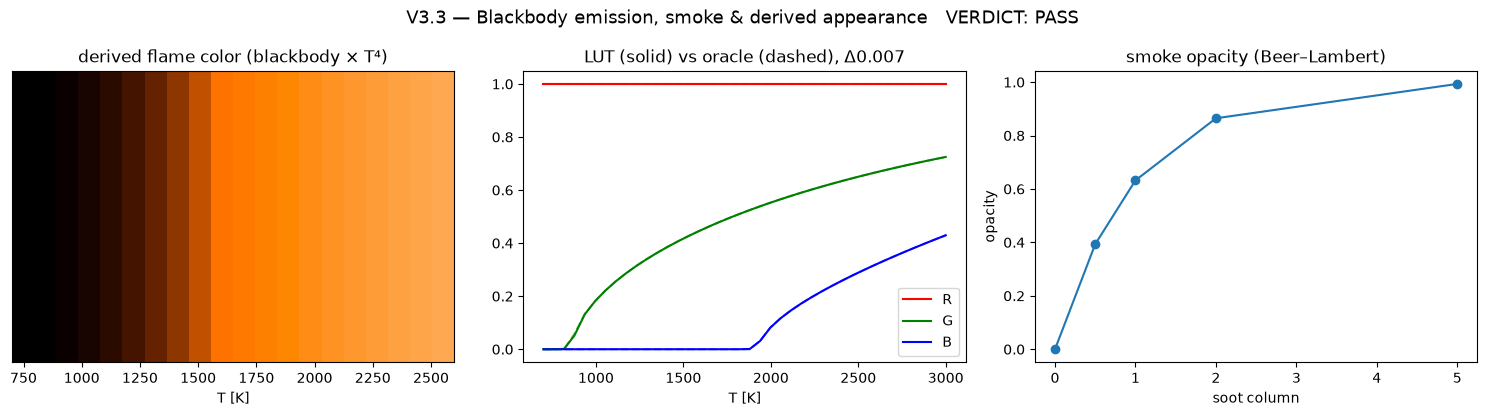

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
# Planckian locus swatches
Tsw = np.linspace(700, 2600, 20); sw = ap.blackbody_rgb(Tsw)
ax[0].imshow((sw*ap.emission_intensity(Tsw)[:,None])[None,:,:], aspect='auto', extent=[700,2600,0,1])
ax[0].set_title('derived flame color (blackbody × T⁴)'); ax[0].set_xlabel('T [K]'); ax[0].set_yticks([])
ax[1].plot(Ts, lut[:,0],'r',label='R'); ax[1].plot(Ts, lut[:,1],'g',label='G'); ax[1].plot(Ts, lut[:,2],'b',label='B')
ax[1].plot(Ts, orc[:,0],'r--',alpha=0.5); ax[1].plot(Ts, orc[:,1],'g--',alpha=0.5); ax[1].plot(Ts, orc[:,2],'b--',alpha=0.5)
ax[1].set_title(f'LUT (solid) vs oracle (dashed), Δ{R["C1_parity"]:.3f}'); ax[1].set_xlabel('T [K]'); ax[1].legend()
ax[2].plot(col, ap.smoke_alpha(col),'o-'); ax[2].set_title('smoke opacity (Beer–Lambert)'); ax[2].set_xlabel('soot column'); ax[2].set_ylabel('opacity')
C1=R['C1_parity']<0.05; C2=R['C2_mono'] and R['C2_red900']; C3=abs(R['C3_ratio']-16)<1e-6 and R['C3_coldoff']==0
C4=R['C4_chardark'] and R['C4_charrough'] and R['C4_wetdark'] and R['C4_emit'] and R['C4_charref']<0.02
C5=R['C5_smoke']<1e-9
allpass=C1 and C2 and C3 and C4 and C5
fig.suptitle(f'V3.3 — Blackbody emission, smoke & derived appearance   VERDICT: {"PASS" if allpass else "FAIL"}', fontsize=13)
fig.tight_layout(); fig.savefig('results/V3_3_emission_appearance.png', dpi=110, bbox_inches='tight')
print('saved results/V3_3_emission_appearance.png')
assert allpass, 'V3.3 criteria not all met'
print('\nV3.3 PASS — fire color is blackbody, smoke is Beer–Lambert, surface is derived from state.')